# Shoreline change trends from CASSIE shorelines - Terschelling

In [1]:
overwrite = False

## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import geopandas as gpd
import numpy as np
import pickle
from shapely import get_coordinates
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib import gridspec
import cartopy.crs as ccrs

from coastal_data import CD_combine_data, CD_geometry, CD_visualisation, CD_statistics, CD_helper_functions, CD_jarkus_tools

from coastsat import SDS_transects, SDS_tools

In [3]:
epsg_local = 32631
# epsg_local = 28992

In [4]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_shorelines = path_to_data_folder + '12_13_Ters_DEM/input/'
path_dem = path_to_data_folder + '12_13_Ters_DEM/output/'
path_tides = path_to_data_folder + '01_tides/output/'
path_altimetry_output = path_to_data_folder + '11_Ters_altimetry/output/'
path_input_general = path_to_data_folder + '0_input_general/'
path_jarkus = path_to_data_folder + '/0_input_general/'

path_output = path_to_data_folder + '14_24_34_RS_shoreline_changes/output/'

In [5]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Get data

In [6]:
# Altimetry
fn = 'tp_plus_ales_epsg28992.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [7]:
# Cassie shorelines
folders = ['12_cassie_landsat_1984-04-30_1992-09-04_ext1000_spac5000_base2_multi-thresh/',\
          '13_cassie_landsat_1992-09-20_2003-08-02_ext1000_spac5000_base2_multi-thresh/',\
          '18_cassie_landsat_2003-09-19_2015-03-12_ext1300_spac5000_base1_multi-thresh/',\
          '17_cassie_landsat_2015-04-13_2023-02-22_ext1300_spac5000_base1_multi-thresh/']
sl_cassie = CD_combine_data.combine_cassie(path_shorelines+'/1_shorelines_cassie/', folders, epsg=epsg_local)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]
sl_cassie_red = {'dates': c_dates, 'shorelines': c_shorelines}

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

118 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 790 points (min: 156, max: 1475).


In [8]:
# Load outlier-corrected shorelines
c_shorelines_corr = pickle.load(open(path_dem + 'c_shorelines_corr.pkl', 'rb'))
c_shorelines_corr = np.array([sl for sl in c_shorelines_corr if len(sl) > 0], dtype='object') # remove empty shoreline
c_dates = np.delete(c_dates, 22)

sllist = []
for sl in c_shorelines_corr:
    sl_list_temp = CD_geometry.transform_general_geom_list(sl, 4326, epsg_local)
    sllist.append(np.array(sl_list_temp))

sl_cassie_corr = {'dates': c_dates, 'shorelines': np.array(sllist, dtype=object)}

pickle.dump(c_dates, open(path_output+'c_dates_Ters.pkl', 'wb'))

## Create transects

In [9]:
med_sl = CD_geometry.median_shoreline_from_transect_intersections(c_shorelines_corr, spacing=100, transect_length=5000, smooth_factor=100)

In [10]:
# med_sl = CD_geometry.switch_linestring_xy(med_sl)
med_sl = CD_geometry.transform_linestring(med_sl, 4326, epsg_local)
med_sl = CD_geometry.smooth_LineString(med_sl, n=25)

In [11]:
transects = CD_geometry.create_transects(med_sl, spacing=1000, transect_length=2000, save_path=None, save_fn=None)
print(f'Created {len(transects)} transects.')

transects = transects['transect'][0:-1:3].reset_index()
transects = transects.drop([1,2,4,6,8])
print(f'Reduced to {len(transects)} transects.')

transect_coords = {i: get_coordinates(transect) for i, transect in enumerate(transects['transect'])}
# switch start and end point of the transects
for key in transect_coords:
    transect_coords[key] = transect_coords[key][::-1]

transects.to_pickle((path_output+'transects_Ters.pkl'))

Created 640 transects.
Reduced to 208 transects.


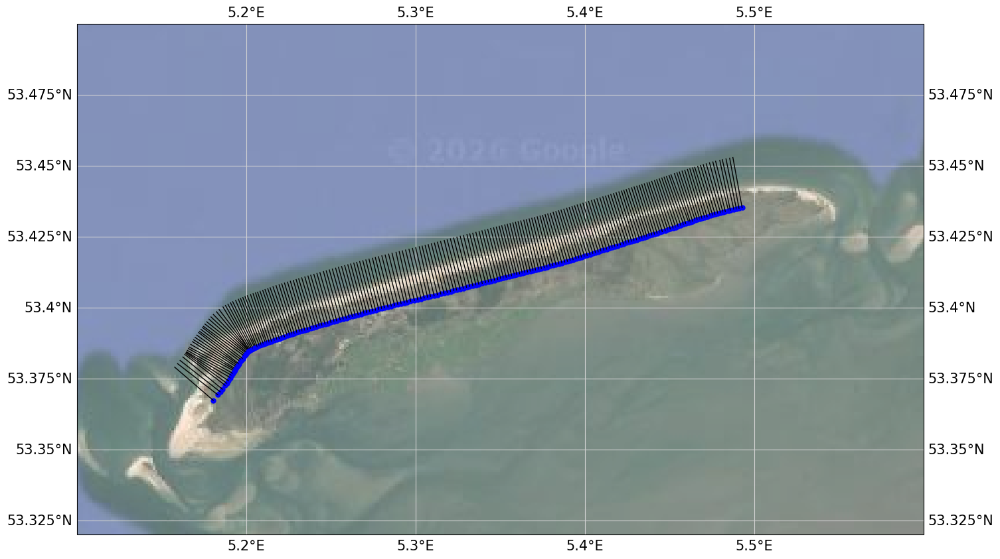

In [12]:
projection = ccrs.epsg(epsg_local)
extent = [5.1, 5.6, 53.32, 53.5]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=10)
for key in list(transect_coords.keys()):
    # origins, need to be landwards for coastsat intersection computation
    ax.plot(transect_coords[key][0,0],transect_coords[key][0,1], 'bo', ms=5, transform=projection)
    ax.plot(transect_coords[key][:,0],transect_coords[key][:,1],'k-',lw=1, transform=projection)

## Load JARKUS transects
Problem: JARKUS transects are much longer in cross-shore direction, and don't intersect with the volume polygons (to separate between shoreline change trends west/center/east)

## Compute intersections

In [13]:
fn_cd = 'cd_cassie_sm_Ters.pkl'
if (not os.path.isfile(path_output + fn_cd)) | overwrite:
    settings_transects = {
                'along_dist': 1200,     # along-shore distance to use for computing the intersection
                'max_dist_origin': 10000,     # maximum distance to the origin of a transect in [m]
                             }
    cd_cassie = SDS_transects.compute_intersection(sl_cassie_corr, transect_coords, settings_transects)
    
    cd_cassie_sm = {}
    for key in cd_cassie.keys():
        # Interpolate over the nans
        cd_cassie[key] = np.array(pd.Series(cd_cassie[key]).interpolate())
        # Smooth
        cd_cassie_sm[key] = CD_statistics.moving_average(cd_cassie[key], 5)
    
    pickle.dump(cd_cassie_sm, open(path_output+fn_cd, 'wb'))
else:
    cd_cassie_sm = pickle.load(open(path_output+fn_cd, 'rb'))
    print(f'Loaded {fn_cd} from {path_output}')

Loaded cd_cassie_sm_Ters.pkl from /media/bene/Seagate/PhD-data/98_paper2_kf_dtm/14_24_34_RS_shoreline_changes/output/


## Tide correction

In [14]:
# Tide model
fn = 'tides_ters.csv'
tidal_corr = pd.read_csv(path_tides+fn, index_col='dates', parse_dates=['dates'])

# Interpolate tides onto cassie time stamps
dates_tides = CD_helper_functions.datetime_to_decimal_numbers(tidal_corr.index)
dates_cassie = CD_helper_functions.datetime_to_decimal_numbers(pd.to_datetime(c_dates))

tides_at_cassie_times = np.interp(dates_cassie, dates_tides, tidal_corr['corr_eot[m]'])

beach_slope = -0.01
cd_tcorr = CD_combine_data.tidal_correction(cd_cassie_sm, tides_at_cassie_times, beach_slope)

pickle.dump(cd_tcorr, open(path_output+'cd_tcorr_Ters.pkl', 'wb'))

## Plots

In [15]:
# plot timeseries for all transects
fig = plt.figure(figsize=[20,400])
gs = gridspec.GridSpec(len(cd_tcorr),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)
for i,key in enumerate(cd_tcorr.keys()):
    if np.all(np.isnan(cd_tcorr[key])):
        continue
    ax = fig.add_subplot(gs[i,0])
    ax.grid(linestyle=':', color='0.5')
    
    ax.plot(c_dates, cd_cassie_sm[key], '-o', ms=6, mfc='w', label='CASSIE uncorrected')
    ax.plot(c_dates, cd_tcorr[key], '-o', ms=6, mfc='w', label='CASSIE with tidal correction')
    
    ax.set_ylabel('distance [m]')
    ax.text(0.5,0.95, f'transect {key}', bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center', va='top', transform=ax.transAxes, fontsize=14)
ax.legend(loc='upper right', fontsize='large');

## Trends

In [16]:
poly_sl_corr = pickle.load(open(path_dem + f'poly_sl_corr{4326}.pkl', 'rb'))
jarkus = xr.open_dataset(path_jarkus + 'transect_red_with_derivatives.nc')

In [17]:
_, poly_west, poly_center, poly_east = CD_jarkus_tools.get_Ters_section_polygons(poly_sl_corr, jarkus, buffer_vol=0)

Reduced target polygon by 0.0 %


In [18]:
poly_west_local = CD_geometry.transform_polygon(poly_west, 4326, epsg_local)
poly_center_local = CD_geometry.transform_polygon(poly_center, 4326, epsg_local)
poly_east_local = CD_geometry.transform_polygon(poly_east, 4326, epsg_local)

In [19]:
# Which transects are in which area
idx_west, = np.where(transects.intersects(poly_west_local))
idx_center, = np.where(transects.intersects(poly_center_local))
idx_east, = np.where(transects.intersects(poly_east_local))

cd_west = {key: cd_tcorr[key] for key in idx_west}
cd_center = {key: cd_tcorr[key] for key in idx_center}
cd_east = {key: cd_tcorr[key] for key in idx_east}

In [20]:
trend_all, trend_all_tcorr = [], []
for transect in cd_cassie_sm.keys():
    trend_all.append(CD_statistics.compute_trend(dates_cassie, cd_cassie_sm[transect]))
    trend_all_tcorr.append(CD_statistics.compute_trend(dates_cassie, cd_tcorr[transect]))

trend_west = []
for transect in cd_west.keys():
    trend_west.append(CD_statistics.compute_trend(dates_cassie, cd_west[transect]))

trend_center = []
for transect in cd_center.keys():
    trend_center.append(CD_statistics.compute_trend(dates_cassie, cd_center[transect]))

trend_east = []
for transect in cd_east.keys():
    trend_east.append(CD_statistics.compute_trend(dates_cassie, cd_east[transect]))

In [34]:
print(f'Entire coastline, median trend: {round(np.median(trend_all_tcorr),2)} m/year, mean trend: {round(np.mean(trend_all_tcorr),2)} m/year')
print(f'Min trend: {round(np.min(trend_all_tcorr),2)} m/year, max trend: {round(np.max(trend_all_tcorr),2)} m/year \n')

print(f'West, median trend: {round(np.median(trend_west),2)} m/year, mean trend: {round(np.mean(trend_west),2)} m/year')
print(f'Center, median trend: {round(np.median(trend_center),2)} m/year, mean trend: {round(np.mean(trend_center),2)} m/year')
print(f'East, median trend: {round(np.median(trend_east),2)} m/year, mean trend: {round(np.mean(trend_east),2)} m/year')

Entire coastline, median trend: 1.68 m/year, mean trend: 1.11 m/year
Min trend: -11.05 m/year, max trend: 8.6 m/year 

West, median trend: -2.25 m/year, mean trend: -2.37 m/year
Center, median trend: 5.75 m/year, mean trend: 5.4 m/year
East, median trend: -3.07 m/year, mean trend: -3.24 m/year


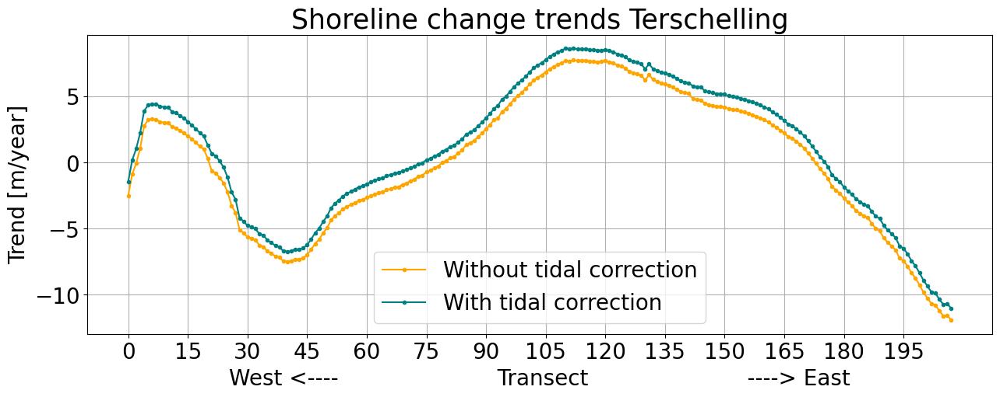

In [22]:
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(cd_cassie_sm.keys(), trend_all, '.-', label='Without tidal correction', color='orange')
ax.plot(cd_cassie_sm.keys(), trend_all_tcorr, '.-', label='With tidal correction', color='teal')

# ax.plot(cd_west.keys(), trend_west, '.-', label='Sections (with tc)', color='darkorange')
# ax.plot(cd_center.keys(), trend_center, '.-', color='brown')
# ax.plot(cd_east.keys(), trend_east, '.-', color='darkorange')

ax.legend()
ax.set_ylabel('Trend [m/year]')
ax.set_xlabel('West <----                       Transect                       ----> East')
xticks = list(cd_cassie_sm.keys())[0::15]
ax.set_xticks(xticks)
ax.set_title('Shoreline change trends Terschelling')
ax.grid()

plt.savefig(f'{path_output}Ters_RS_shoreline_trends.png', dpi=300, bbox_inches='tight')

## Map

In [23]:
inter = transects.intersection(med_sl)

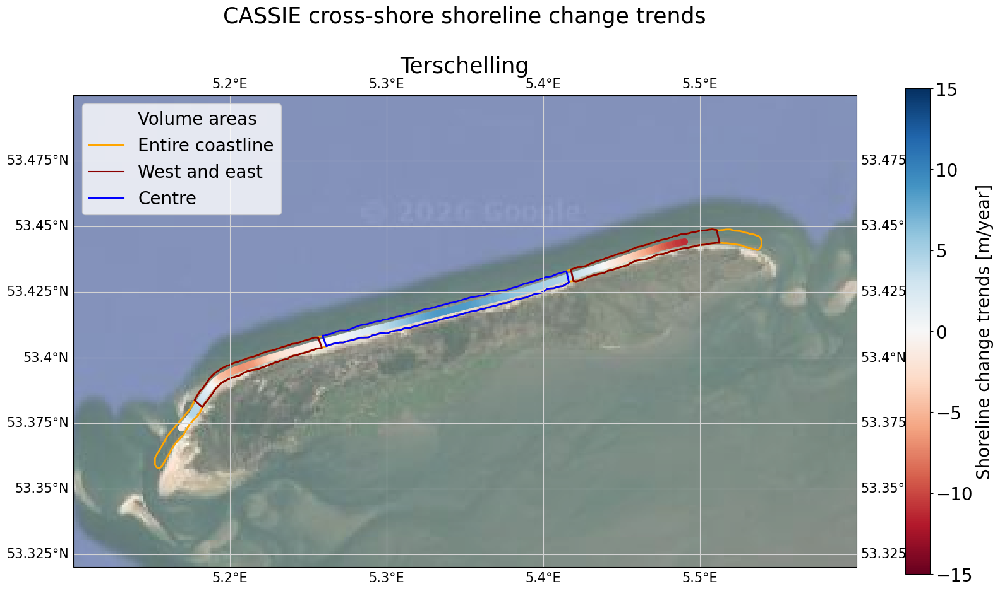

In [24]:
extent = [5.1, 5.6, 53.32, 53.5]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=10)

plot = ax.scatter(inter.geometry.x, inter.geometry.y, c=trend_all_tcorr, transform=ccrs.epsg(epsg_local),
                  s=50, cmap='RdBu', vmin=-15, vmax=15)
plt.colorbar(plot, shrink=1, label='Shoreline change trends [m/year]')
ax.set_title('CASSIE cross-shore shoreline change trends\n\nTerschelling')

lw = 2
ax.add_geometries(poly_sl_corr, facecolor='none', edgecolor='orange', crs=ccrs.PlateCarree(), lw=lw)
ax.add_geometries(poly_west, facecolor='none', edgecolor='darkred', crs=ccrs.PlateCarree(), lw=lw)
ax.add_geometries(poly_center, facecolor='none', edgecolor='blue', crs=ccrs.PlateCarree(), lw=lw)
ax.add_geometries(poly_east, facecolor='none', edgecolor='darkred', crs=ccrs.PlateCarree(), lw=lw)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='none', label='Volume areas', lw=0, ms=0),  # Subtitle
    Line2D([0], [0], color='orange', label='Entire coastline'),
    Line2D([0], [0], color='darkred', label='West and east'),
    Line2D([0], [0], color='blue', label='Centre'),
    ]
ax.legend(handles=legend_elements, loc='upper left')

plt.savefig(f'{path_output}Ters_map_trends_and_areas.png', dpi=300, bbox_inches='tight')